# 1. Far funzionare una piattaforma per i big data

In [ ]:
# @title Installazione della API PySpark in Google Colab (fonte: https://colab.research.google.com/drive/1fa2G3YuXx3Isqyby5kFETqmWotFwtqlH?usp=sharing#scrollTo=hxv7w_2y2bb9)
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.2.1-bin-hadoop3.2"

import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F

spark= SparkSession \
       .builder \
       .appName("Breast Cancer Analysis") \
       .getOrCreate()

spark

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,942 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,

# 2. Importare un dataset (citando la fonte)

In [ ]:
# @title Creazione di un dataframe (sdf) dal dataset "Breast_cancer_dataset.csv" (fonte: https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset)
sdf = spark.read.csv("/content/Breast_cancer_dataset.csv", header=True, inferSchema=True)

Il set di dati proviene dal Breast Cancer Wisconsin (Diagnostic) Data Set, un benchmark ampiamente utilizzato nell'apprendimento automatico per la diagnostica medica. Contiene misurazioni dettagliate dei nuclei cellulari da campioni di tessuto mammario, consentendo la classificazione dei tumori come benigni (non cancerosi) o maligni (cancerosi).

## Obiettivi dell'analisi

Ho scelto il presente dataset perché interessato alle applicazioni della scienza dei dati in ambito biomedico, e poter trarre utili informazioni da dati reali sulla diagnostica patologica mi è sembrato un ottimo punto di partenza per eventuali successivi lavori di approfondimento.

Anche se il dataset in questione non presenta dimensioni particolarmente impegnative in termini di consumo delle risorse di calcolo, per assolvere agli obiettivi didattici dei corsi di "Piattaforme per i big data" e "Machine learning" del corso di laurea magistrale in ingegneria informatica della Università Telematica Internazionale UniNettuno, partirò non l'utilizzo di una nota piattaforma per la gestione dei big data "Spark" - nella sua implementazione Pyton con la API "PySpark" - creando un dataframe dal file "Breast_cancer_dataset.csv" (di cui ne citerò la fonte).

I primi passi dell'analisi consisteranno nell'estrapolare un sottoinsieme ridotto di dati e, utilizzando la nota distribuzione API Pandas, nell'ottenere le classiche informazioni descrittive di carattere strutturale del dataset (nomi delle colonne, tipi dei dati, presenza di campi vuoti o duplicati, etc.).

Successivamente, tornerò a gestire il dataset originario effettuando operazioni di pulizia e aggregazione dei dati finalizzate all'ottenimento di un nuovo dataframe costituito da un sottoinsieme di interesse per gli obiettivi dell'analisi.

Riprendendo l'utilizzo della ricca libreria delle classi di Pandas, effettuerò inizialmente analisi di tipo esplorativo; successivamente - servendomi di note tecniche di data visualization - ricercherò possibili correlazioni fra le più significative delle variabili disponibili e la classificazione dei tumori.

In ultima analisi, implementerò alcuni fra i più noti algoritmi di machine learning che, con un addestramento basato su una selezione di dati che limiti il fenomeno dell'overfitting, riclassifichi i tumori con un livello di attendibilità utile a possibili applicazioni future.

# 3. Data exploration su un sottoinsieme del dataset usando le librerie Pandas

In [ ]:
# @title Stampa delle dimensioni del dataframe
print(f"{sdf.count()} Rows x {len(sdf.columns)} Columns")

569 Rows x 33 Columns


In [ ]:
# @title Creazione di un nuovo dataframe (sdf2) con le prime 50 righe del dataset
sdf2 = sdf.limit(50)

In [ ]:
# @title Conversione (con Arrow) da PySpark dataframe (sdf2) a Pandas dataframe (pdf2)
pdf2 = sdf2.toPandas()

In [ ]:
# @title Installazione delle API Pandas (fonte: https://pandas.pydata.org/) e NumPy (fonte: https://pypi.org/project/numpy/)
!pip install pandas
!pip install numpy

import pandas as pd
import numpy as np

In [ ]:
# @title Stampa delle prime 5 righe (head)
pdf2.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,_c32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,None
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,None
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,None
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,None
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,None


In [ ]:
# @title Stampa delle info sul dataframe (colonne, conteggi valori nulli, tipi)
pdf2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       50 non-null     int32  
 1   diagnosis                50 non-null     object 
 2   radius_mean              50 non-null     float64
 3   texture_mean             50 non-null     float64
 4   perimeter_mean           50 non-null     float64
 5   area_mean                50 non-null     float64
 6   smoothness_mean          50 non-null     float64
 7   compactness_mean         50 non-null     float64
 8   concavity_mean           50 non-null     float64
 9   concave points_mean      50 non-null     float64
 10  symmetry_mean            50 non-null     float64
 11  fractal_dimension_mean   50 non-null     float64
 12  radius_se                50 non-null     float64
 13  texture_se               50 non-null     float64
 14  perimeter_se             50 

In [ ]:
# @title Ricerca di eventuali valori che si ripetono nei record
pdf2.duplicated().any()

np.False_

In [ ]:
# @title Installazione della API Matplotlib (fonte: https://pypi.org/project/matplotlib/)
!pip install matplotlib

import matplotlib.pyplot as plt

In [ ]:
# @title Installazione della API Seaborn (fonte: https://seaborn.pydata.org/)
!pip install seaborn

import seaborn as sns

In [ ]:
# @title Creazione di un nuovo dataframe (pdf3) senza le colonne "id", "diagnosis" e "_c32"
pdf3 = pdf2.drop(["id", "diagnosis", "_c32"], axis=1)

In [ ]:
# @title Calcolo dei principali indici statistici
pdf3.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,50.000000,50.000000,50.00000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,15.377200,20.178400,101.40000,761.998000,0.104082,0.142035,0.133984,0.073518,0.198400,0.065274,...,18.747880,27.749400,126.08400,1136.740000,0.14796,0.401044,0.436152,0.171340,0.350270,0.099033
std,3.011576,3.828225,20.43648,294.515104,0.013052,0.059840,0.068864,0.032298,0.030680,0.008908,...,4.412258,5.752249,30.85433,536.175767,0.02447,0.218684,0.215796,0.061182,0.087623,0.028010
min,8.196000,10.380000,51.71000,201.900000,0.081620,0.037660,0.015880,0.005917,0.146700,0.052780,...,8.964000,15.660000,57.26000,242.200000,0.09387,0.046190,0.023980,0.025640,0.156500,0.055040
25%,13.197500,17.797500,86.36250,537.250000,0.094998,0.102325,0.088590,0.052852,0.178650,0.058680,...,15.475000,23.495000,102.95000,739.575000,0.13275,0.212675,0.273700,0.144925,0.289025,0.079850
50%,15.145000,20.825000,99.90500,701.600000,0.102750,0.133200,0.133350,0.074965,0.190150,0.063365,...,17.845000,28.060000,123.60000,962.050000,0.14925,0.386900,0.426350,0.179750,0.356050,0.096120
75%,17.885000,22.532500,118.70000,989.525000,0.112850,0.171425,0.194525,0.094617,0.217825,0.070050,...,22.015000,31.540000,151.42500,1446.500000,0.16400,0.555700,0.557575,0.209325,0.401650,0.111025
max,21.160000,27.540000,137.20000,1404.000000,0.142500,0.283900,0.300100,0.147100,0.304000,0.097440,...,29.170000,40.680000,188.00000,2615.000000,0.20980,1.058000,1.105000,0.270100,0.663800,0.207500


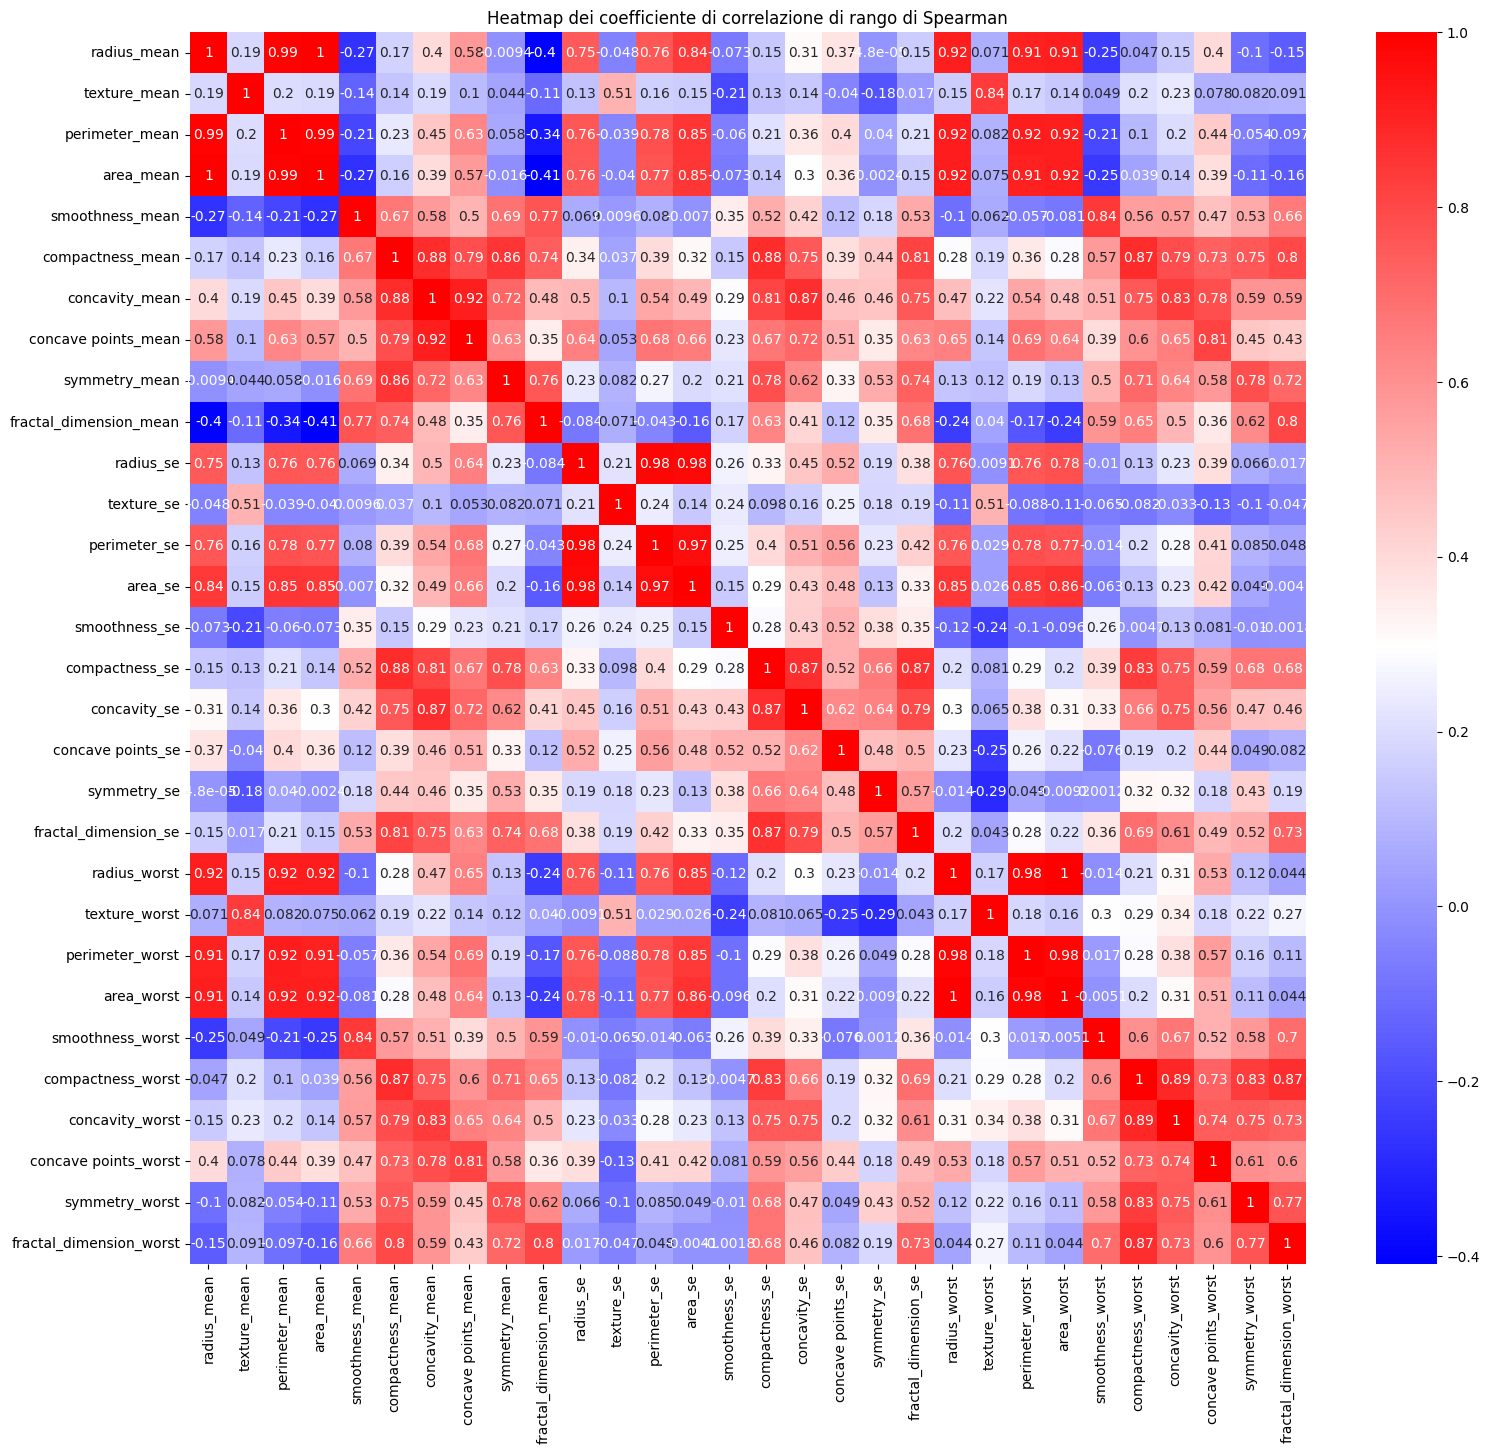

In [ ]:
# @title Heatmap dei coefficienti di correlazione di rango di Spearman
plt.figure(figsize=(18,16))
sns.heatmap(pdf3.corr(method='spearman'), cmap='bwr', annot=True)
plt.title('Heatmap dei coefficiente di correlazione di rango di Spearman')
plt.show()

# 4. Data exploration per conferma e data cleaning su tutto il dataset

Secondo il coefficiente di rango di Spearman, i valori vicini all'unità sarebbero altamente correlabili; anche i valori prossimi allo zero potrebbero risultare potenzialmente correlabili secondo tale coefficiente.

Dalla heatmap di cui sopra si osserva una certa ripetitività nella correlazione fra i parametri di misura afferenti alle tre categorie contemplate nel dataset: Valori medi, Errore standard, Valori peggiori.

Ho deciso, quindi, di concentrare il resto dell'analisi sui campi relativi ai valori medi delle misurazioni. Proseguirò, dunque, riconsiderando tutte le righe del dataset di partenza, ma estrapolando solo i dati appartenenti alle colonne: "diagnosis", "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean".

In [ ]:
# @title Stampa delle prime 5 righe
sdf.show(n=5)

+--------+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+---------+----------+------------+-------+-------------+--------------+------------+-----------------+-----------+--------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+----+
|      id|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|radius_se|texture_se|perimeter_se|area_se|smoothness_se|compactness_se|concavity_se|concave points_se|symmetry_se|fractal_dimension_se|radius_worst|texture_worst|perimeter_worst|area_worst|smoothness_worst|compactness_worst|concavity_worst|concave points_worst|symmetry_worst|fractal_dimension_worst|_c32|
+--------+---------+-----------+------

In [ ]:
# @title Stampa delle info sul dataframe (colonne, tipi)
sdf.printSchema()

root
 |-- id: integer (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- radius_mean: double (nullable = true)
 |-- texture_mean: double (nullable = true)
 |-- perimeter_mean: double (nullable = true)
 |-- area_mean: double (nullable = true)
 |-- smoothness_mean: double (nullable = true)
 |-- compactness_mean: double (nullable = true)
 |-- concavity_mean: double (nullable = true)
 |-- concave points_mean: double (nullable = true)
 |-- symmetry_mean: double (nullable = true)
 |-- fractal_dimension_mean: double (nullable = true)
 |-- radius_se: double (nullable = true)
 |-- texture_se: double (nullable = true)
 |-- perimeter_se: double (nullable = true)
 |-- area_se: double (nullable = true)
 |-- smoothness_se: double (nullable = true)
 |-- compactness_se: double (nullable = true)
 |-- concavity_se: double (nullable = true)
 |-- concave points_se: double (nullable = true)
 |-- symmetry_se: double (nullable = true)
 |-- fractal_dimension_se: double (nullable = true)
 |-- radi

In [ ]:
# @title Ricerca di eventuali record con stesso "id"
if sdf.count() == sdf.dropDuplicates(subset=['id']).count():
  print('False')
else:
  print('True')

False


In [ ]:
# @title Calcolo dei principali indici statistici
sdf.summary().show()

+-------+--------------------+---------+------------------+-----------------+-----------------+-----------------+--------------------+-------------------+-------------------+--------------------+--------------------+----------------------+------------------+------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+------------------+------------------+-----------------+--------------------+-------------------+-------------------+--------------------+-------------------+-----------------------+----+
|summary|                  id|diagnosis|       radius_mean|     texture_mean|   perimeter_mean|        area_mean|     smoothness_mean|   compactness_mean|     concavity_mean| concave points_mean|       symmetry_mean|fractal_dimension_mean|         radius_se|        texture_se|      perimeter_se|          area_se|       smoothness_se|      compactness_

Si osservi come il valore dei principali indici statistici non cambi significativamente dall'analisi effettuata su 50 unità a quella ripetuta per l'intero dataset di 569 record.

In [ ]:
# @title Estrarre un dataframe di interesse (sdf4)
sdf4 = sdf.select("diagnosis", "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean")
sdf4.show(n=5)

+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+
|diagnosis|radius_mean|texture_mean|perimeter_mean|area_mean|smoothness_mean|compactness_mean|concavity_mean|concave points_mean|symmetry_mean|fractal_dimension_mean|
+---------+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+
|        M|      17.99|       10.38|         122.8|   1001.0|         0.1184|          0.2776|        0.3001|             0.1471|       0.2419|               0.07871|
|        M|      20.57|       17.77|         132.9|   1326.0|        0.08474|         0.07864|        0.0869|            0.07017|       0.1812|               0.05667|
|        M|      19.69|       21.25|         130.0|   1203.0|         0.1096|          0.1599|        0.1974|             0.1279|       0.2069|               0.05999

In [ ]:
# @title Conversione (con Arrow) da PySpark dataframe (sdf4) a Pandas fataframe (pdf4)
pdf4 = sdf4.toPandas()

# 5. Data analysis e data visualizazion con Pandas

In [ ]:
# @title Conteggio dei casi di tumore benigno (B) e di tumore maligno (M)
pdf4['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


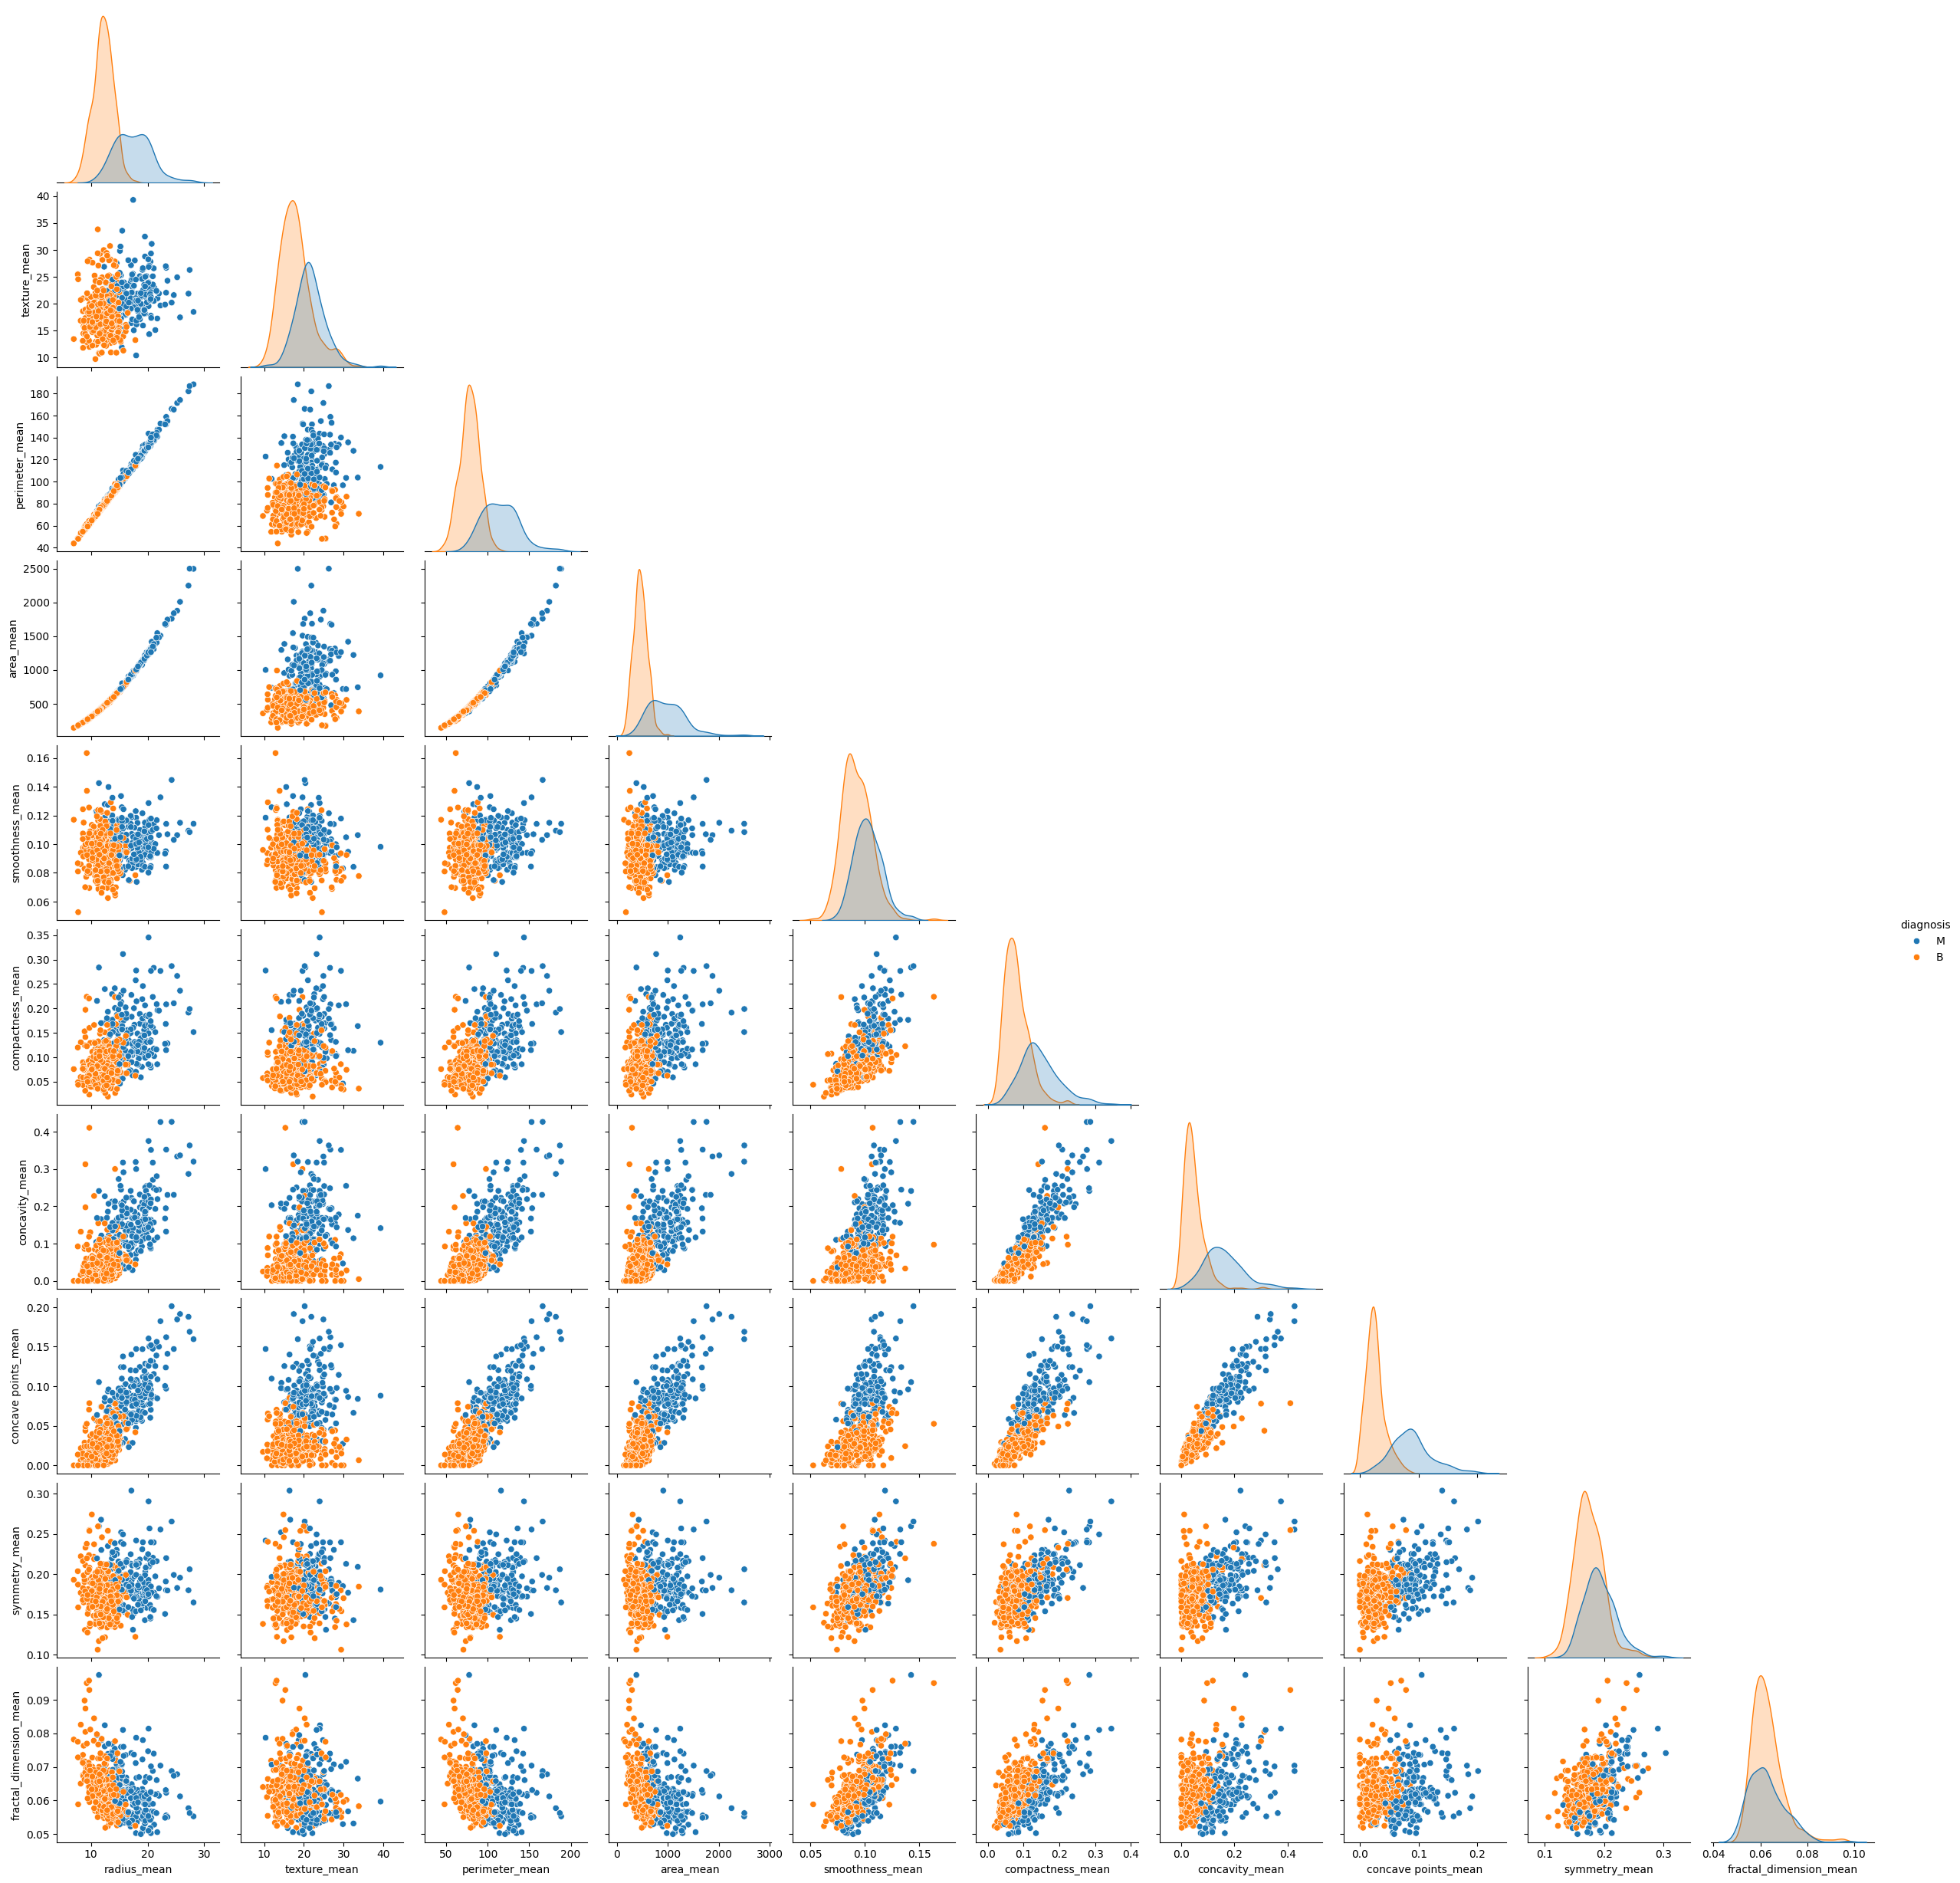

In [ ]:
# @title Scatter Matrix con distinzione dei dati per diagnosi
sns.pairplot(pdf4, hue="diagnosis", corner=True)

Dalla matrice presentata si evince la ovvia correlabiità fra le misure medie dei raggi e le rispettive misure medie di perimetro e area. Considerazioni analoghe possono esser fatte fra la concavità media e la media delle porzioni concave nel contorno.

La distinzione fatta fra i campioni cancerosi (M) e non-cancerosi (B), negli scatter plot generati, ha consentito di riconoscere visivamente i due pattern; inoltre, tale distinzione risulta particolarmente evidente per alcune coppie fra gli attributi considerati.

Utili indicazioni sono fornite anche dalla diagonale delle KDE (Kernel Density Estimation), dalla quale si evince una sostanziale sovrapposizione nella classificazione della diagnosi per i campi relativi a "texture_mean", "smoothness_mean", "symmetry_mean" e "fractal_dimension_mean".

In ragione delle osservazioni espresse ho deciso di considerare come variabili di interesse per le successive analisi il raggio, la compattezza e la concavità.

In [ ]:
# @title Creazione di un nuovo dataframe ridotto (pdf5)
pdf5 = pdf4.drop(["texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "concave points_mean", "symmetry_mean", "fractal_dimension_mean"], axis=1)

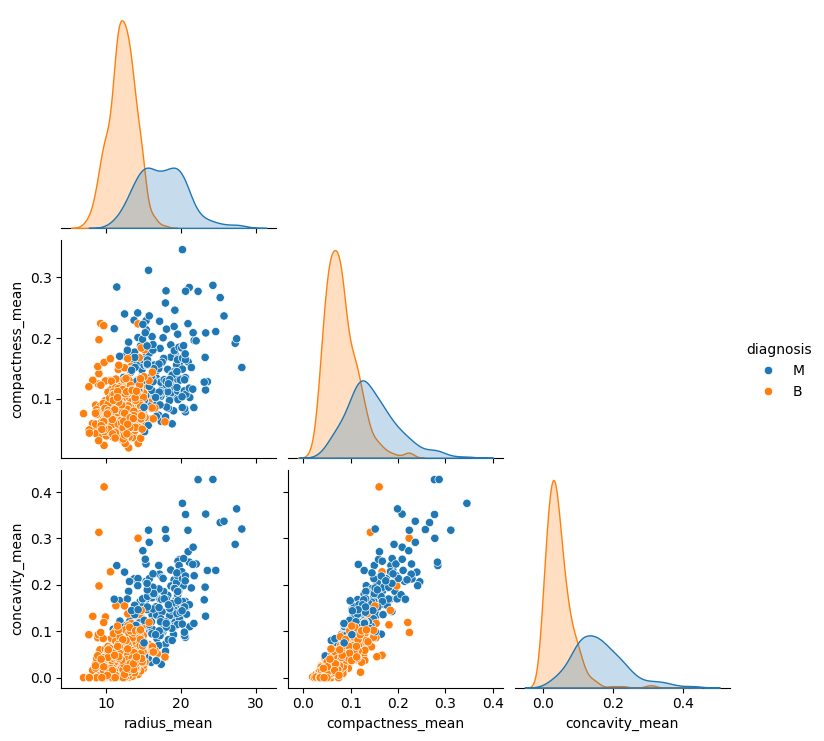

In [ ]:
# @title Scatter Matrix ridotta con distinzione dei dati per diagnosi
sns.pairplot(pdf5, hue="diagnosis", corner=True)

In [ ]:
# @title Installazione della API Plotly e importazione della libreria Plotly express (fonte: https://plotly.com/python/)
!pip install plotly

import plotly.express as px

Come ultimo approfondimento della presente analisi - prima di passare alla creazione di un opportuno modello di machine learning - ho ritenuto utile rimarcare come la distinzione fra i pattern della diagnosi dei casi registrati si mostri particolarmente chiara al variare delle tre variabili considerate; la seguente rappresentazione (interattiva) in scatter plot tridimensionale ne agevola l'osservazione.

In [ ]:
# @title 3D Scatter Plot delle variabili “radius_mean”, “compactness_mean” e “concavity_mean”
fig = px.scatter_3d(pdf5, x='radius_mean', y='compactness_mean', z='concavity_mean',
              color='diagnosis', opacity= 0.75, width=1150, height=950)
fig.show()

## Prime considerazioni sull'analisi condotta

La visualizzazione interattiva appena mostrata ha evidenziato - a meno di qualche valore anomalo (outlier) - una maggiore concentrazione dei casi di tumore cancerosi all'aumentare delle metriche considerate. Di contro, la restante compagine con diagnosi bengigna risulta addensata in un range ridotto degli stessi parametri.

# 6. Creare un modello di Machine Learning per una predizione o classificazione

In [ ]:
# @title Installazione della API scikit-learn (fonte: https://scikit-learn.org/stable/)
!pip install scikit-learn

import sklearn

In [ ]:
# @title Importazione delle librerie utili
from sklearn.model_selection import train_test_split    # metodo per separate i dati di addestramento dai dati di test
from sklearn.preprocessing import RobustScaler          # metodo per ridurre dimensionalità e outliers nel dataset
from sklearn.metrics import accuracy_score              # metodo per calcolare l'accuratezza della stima
from sklearn.metrics import precision_score             # metodo per calcolare la precisione della stima
from sklearn.metrics import f1_score                    # metodo per calcolare il punteggio F1 della stima
from sklearn.metrics import RocCurveDisplay             # metodo per visualizzare la curva ROC

# Classificatori
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.ensemble import RandomForestClassifier     # non richiede la riduzione in scala delle caratteristiche
from sklearn.tree import DecisionTreeClassifier         # non richiede la riduzione in scala delle caratteristiche

### Generazione di un nuovo dataframe (pdf6) con mappatura della diagnosi (M:0, B:1)

La codifica (in numeri interi) dei dati categorici (in formato stringa) relativi alla diagnosi favorisce gli algoritmi di machine learning nell'interpretazione di tali dati durante le fasi di addestramento.

In [ ]:
pdf6 = pdf5.copy()
pdf6['diagnosis'] = pdf6['diagnosis'].map({'M': 0, 'B': 1})

pdf6.head()

,diagnosis,radius_mean,compactness_mean,concavity_mean
0,0,17.99,0.27760,0.3001
1,0,20.57,0.07864,0.0869
2,0,19.69,0.15990,0.1974
3,0,11.42,0.28390,0.2414
4,0,20.29,0.13280,0.1980


### Preparazione dei dataframe di addestramento e test

Nella pratica comune si tende ad aumentare la frazione di dati destinata ai test per dataset modesti. In questo caso ho ritenuto il rapporto 0.2 (test_size) un giusto compromesso per le analisi.

Assegnando un seme casuale fisso (random_state) al generatore interno di numeri pseudo-casuali (il numero 42 ha un mero valore simbolico) si garantisce la riproducibilità dei risultati ottenuti.

Il parametro preposto alla stratificazione (stratify), inoltre, garantirà un'equa distribuzione fra le righe del set di addestramento in funzione delle categorie target (y).

In [ ]:
X = pdf6.drop('diagnosis', axis=1)
y = pdf6['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Riduzione in scala delle caratteristiche

Rendere confrontabile l'ordine di grandezza delle caratteristiche considerate risulta un passaggio fondamentale per il rendimento della maggior parte degli algoritmi di machine learning (dei classificatori prescelti, solo il RandomForest non risulta influenzato dalla scala dei valori). Tale operazione è perseguibile con il metodo StandardScaler() di scikit-learn; tuttavia, adotterò un altro valido metodo di riduzione, il RobustScaler(), che risulta più adatto all'applicazione su dataset minori contenenti valori anomali.

In [ ]:
RS = RobustScaler()

X_train_scaled = RS.fit_transform(X_train)
X_test_scaled = RS.transform(X_test)

In [ ]:
# @title Applicazione di 4 modelli di classificazione scelti
KNC = KNeighborsClassifier()
KNC.fit(X_train_scaled, y_train)
y_predict = KNC.predict(X_test_scaled)

GPC = GaussianProcessClassifier()
GPC.fit(X_train_scaled, y_train)
y_predict2 = GPC.predict(X_test_scaled)

RFC = RandomForestClassifier()
RFC.fit(X_train, y_train)    # ho usato i dati originari perché questo classificatore non risente della scala
y_predict3 = RFC.predict(X_test)

DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)    # ho usato i dati originari perché questo classificatore non risente della scala
y_predict4 = DTC.predict(X_test)

In [ ]:
# @title Calcolo dell'accuratezza nella stima per ciascun modello
y_accuracy = accuracy_score(y_test, y_predict)
y_accuracy2 = accuracy_score(y_test, y_predict2)
y_accuracy3 = accuracy_score(y_test, y_predict3)
y_accuracy4 = accuracy_score(y_test, y_predict4)

print(f"Accuratezza KNeighborsClassifier: {round(y_accuracy, 2)}")
print(f"Accuratezza GaussianProcessClassifier: {round(y_accuracy2, 2)}")
print(f"Accuratezza RandomForestClassifier: {round(y_accuracy3, 2)}")
print(f"Accuratezza DecisionTreeClassifier: {round(y_accuracy4, 2)}")

Accuratezza KNeighborsClassifier: 0.89
Accuratezza GaussianProcessClassifier: 0.9
Accuratezza RandomForestClassifier: 0.9
Accuratezza DecisionTreeClassifier: 0.87


In [ ]:
# @title Calcolo della precisione nella stima per ciascun modello
y_precision = precision_score(y_test, y_predict)
y_precision2 = precision_score(y_test, y_predict2)
y_precision3 = precision_score(y_test, y_predict3)
y_precision4 = precision_score(y_test, y_predict4)

print(f"Precisione KNeighborsClassifier: {round(y_precision, 2)}")
print(f"Precisione GaussianProcessClassifier: {round(y_precision2, 2)}")
print(f"Precisione RandomForestClassifier: {round(y_precision3, 2)}")
print(f"Precisione DecisionTreeClassifier: {round(y_precision4, 2)}")

Precisione KNeighborsClassifier: 0.92
Precisione GaussianProcessClassifier: 0.93
Precisione RandomForestClassifier: 0.94
Precisione DecisionTreeClassifier: 0.94


In [ ]:
# @title Calcolo del punteggio F1 nella stima per ciascun modello
y_F1S = f1_score(y_test, y_predict)
y_F1S2 = f1_score(y_test, y_predict2)
y_F1S3 = f1_score(y_test, y_predict3)
y_F1S4 = f1_score(y_test, y_predict4)

print(f"Punteggio F1 KNeighborsClassifier: {round(y_F1S, 2)}")
print(f"Punteggio F1 GaussianProcessClassifier: {round(y_F1S2, 2)}")
print(f"Punteggio F1 RandomForestClassifier: {round(y_F1S3, 2)}")
print(f"Punteggio F1 DecisionTreeClassifier: {round(y_F1S4, 2)}")

Punteggio F1 KNeighborsClassifier: 0.92
Punteggio F1 GaussianProcessClassifier: 0.92
Punteggio F1 RandomForestClassifier: 0.92
Punteggio F1 DecisionTreeClassifier: 0.89


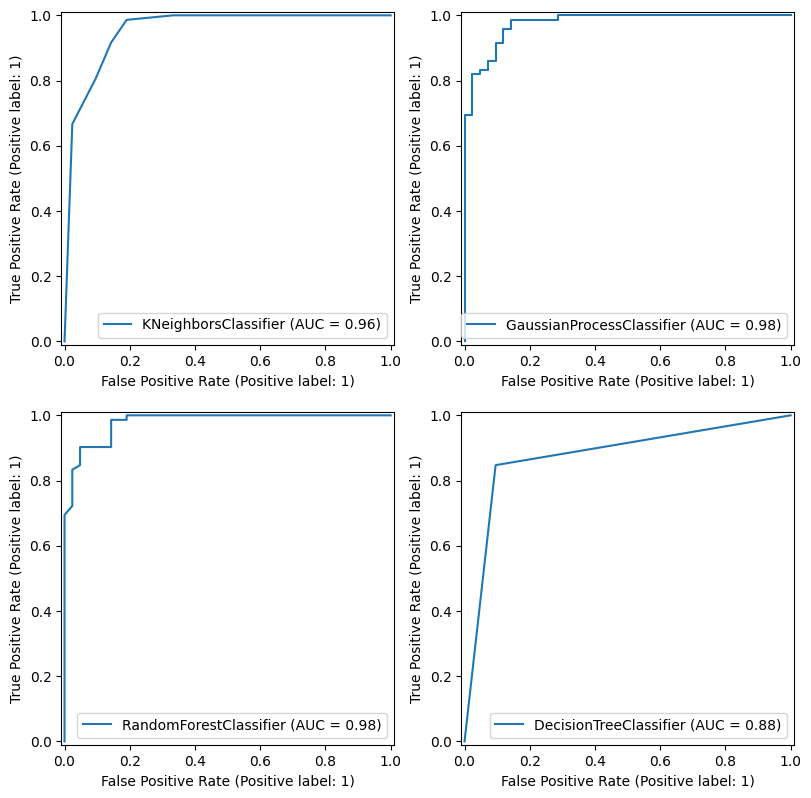

In [ ]:
# @title Generazione della curva di ROC e calcolo del punteggio di AUC per ciascun modello
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
ax_array = fig.subplots(2, 2, squeeze=False)

RocCurveDisplay.from_estimator(KNC, X_test_scaled, y_test, ax=ax_array[0, 0])
RocCurveDisplay.from_estimator(GPC, X_test_scaled, y_test, ax=ax_array[0, 1])
RocCurveDisplay.from_estimator(RFC, X_test, y_test, ax=ax_array[1, 0])
RocCurveDisplay.from_estimator(DTC, X_test, y_test, ax=ax_array[1, 1])

plt.show()

## Considerazioni conclusive

Riporto di seguito una breve descrizione delle metriche considerate nell'ambito del presente progetto per valutare la bontà della stima dei classificatori utilizzati.

### Accuratezza

E' un indice generale che rappresenta la frazione di previsioni esatte (veri positivi e veri negativi) rispetto al numero di tutte le istanze (veri positivi, veri negativi, falsi positivi e falsi negativi).

### Precisione
Rappresenta la frazione di previsioni corrette (veri positivi) rispetto a tutte le istanze positive (veri e falsi). In ambito clinico è un indice molto considerato.

### Punteggio F1
E' definito dalla media armonica di precisione e richiamo; quest'ultimo è dato dal numero di veri positivi rapportato alla somma di veri positivi e falsi negativi. Il punteggo F1 risulta, pertanto, un indice bilanciato, utile a valutare le prestazioni di un algoritmo quando sia i falsi positivi che i falsi negativi sono importanti (come nei casi clinici).

### Curva ROC
E' la rappresentazione grafica dell'andamento della frazione (0-1) dei veri positivi al variare ella frazione (0-1) dei falsi positivi.
La prestazione ottimale di un classificatore mostrerebbe un gomito ben definito nell'angolo in alto a sinistra del grafico.

### AUC (area sotto la curva ROC)
Direttamente collegato alla curva ROC, è un indice di probabilità che il modello scelga un vero positivo rispetto ad un falso positivo in una classificazione binaria.

### **Pensiero critico**
I risultati delle metriche applicate ai classificatori scelti per il lavoro presentato hanno rivelato accuratezza, precisione e un punteggio F1 maggiori per il RandomForest, nonché una migliore qualità della curva ROC, seguita da un alto valore AUC (0,98), per lo stesso algoritmo.

L'esito delle operazioni condotte hanno confermato, pertanto, la bontà delle attività di analisi esplorativa e selezione dei dati, effettuate preliminarmente al fine di estrapolare un dataset idoneo per l'addestramento degli algoritmi di machine learning adottati.